# Ансамбли и анализ

Ноутбук строит ансамбли (Soft Voting + Stacking) на основе топ-3 моделей, выполняет анализ ошибок, feature importance и сохраняет финальные результаты.

## Импорты и загрузка данных

In [5]:
import os
import sys
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from scipy.sparse import hstack

try:
    _project_root = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
except NameError:
    _cwd = os.getcwd()
    _project_root = _cwd
    while _project_root != '/' and not os.path.isdir(os.path.join(_project_root, 'src')):
        _project_root = os.path.dirname(_project_root)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.models.classical import (
    NUMERICAL_COLUMNS,
    prepare_features,
    train_classical_models,
    predict_message,
    save_models,
)
from src.evaluation.metrics import optimize_threshold
from src.config import PROCESSED_DIR, MODELS_DIR, INTERIM_DIR

import optuna
import lightgbm
import catboost
import nltk

nltk.download('stopwords', quiet=True)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings(
    'ignore',
    message='X does not have valid feature names',
    category=UserWarning,
    module='sklearn.utils.validation',
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

In [6]:
with open(INTERIM_DIR / 'features_train.pkl', 'rb') as f:
    train_data = pickle.load(f)
X_train = train_data['X_train']
X_train_nc = train_data['X_train_nc']
y_train = train_data['y_train']

with open(INTERIM_DIR / 'features_test.pkl', 'rb') as f:
    test_data = pickle.load(f)
X_test = test_data['X_test']
X_test_nc = test_data['X_test_nc']
y_test = test_data['y_test']

with open(INTERIM_DIR / 'optuna_models.pkl', 'rb') as f:
    optuna_data = pickle.load(f)
optuna_results = optuna_data['models']

with open(INTERIM_DIR / 'evaluation_results.pkl', 'rb') as f:
    eval_data = pickle.load(f)
all_results = eval_data['all_results']
cv_df = eval_data['cv_df']
top3_keys = eval_data['top3_keys']

df_test = pd.read_csv(PROCESSED_DIR / 'test_preprocessed.csv')
df_test = df_test.dropna(subset=['text_preprocessed']).reset_index(drop=True)

y_test_arr = np.array(y_test)
print(f'Загружено моделей: {len(optuna_results)}')
print(f'Топ-3: {top3_keys}')

Загружено моделей: 5
Топ-3: ['lgbm', 'lr', 'catboost']


Функция для вычисления метрик на тестовой выборке.

In [7]:
def evaluate_on_test(models, X_test, y_test, X_test_nc=None, prefix='base'):
    """Вычисляет метрики для каждой модели на тестовой выборке."""
    results = []
    for name, model in models.items():
        X_eval = X_test_nc if name == 'nb' and X_test_nc is not None else X_test
        y_pred = model.predict(X_eval)
        y_proba = model.predict_proba(X_eval)[:, 1]

        results.append({
            'model': f'{prefix}_{name}',
            'accuracy': float((y_pred == y_test).mean()),
            'precision_spam': float(precision_score(y_test, y_pred, pos_label=1, zero_division=0)),
            'recall_spam': float(recall_score(y_test, y_pred, pos_label=1, zero_division=0)),
            'f1_spam': float(f1_score(y_test, y_pred, pos_label=1, zero_division=0)),
            'f1_macro': float(f1_score(y_test, y_pred, average='macro', zero_division=0)),
            'roc_auc': float(roc_auc_score(y_test, y_proba)),
            'pr_auc': float(average_precision_score(y_test, y_proba)),
        })
    return pd.DataFrame(results)

## Ансамбли

На основе топ-3 моделей строятся два типа ансамблей:
1. **Soft Voting** — усреднение предсказанных вероятностей
2. **Stacking** — мета-модель (Logistic Regression) поверх базовых моделей

Подготовка оценщиков и обучение ансамблей.

In [8]:
estimators = []
for name in top3_keys:
    model = optuna_results[name]
    estimators.append((name, model))

voting = VotingClassifier(estimators=estimators, voting='soft', n_jobs=1)
voting.fit(X_train, y_train)

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=500, random_state=RANDOM_STATE),
    cv=3,
    n_jobs=1,
)
stacking.fit(X_train, y_train)

print('Ансамбли обучены')

Ансамбли обучены


Оценка ансамблей на тестовой выборке.

In [9]:
ensemble_models = {'voting': voting, 'stacking': stacking}
ensemble_results = evaluate_on_test(ensemble_models, X_test, y_test_arr, prefix='ensemble')
ensemble_results

,model,accuracy,precision_spam,recall_spam,f1_spam,f1_macro,roc_auc,pr_auc
0,ensemble_voting,0.957166,0.994004,0.910958,0.950671,0.956410,0.979702,0.984546
1,ensemble_stacking,0.962605,0.990083,0.926750,0.957370,0.962032,0.982631,0.986234


## Итоговая таблица сравнения

Объединение всех результатов: базовые модели, Optuna-модели, ансамбли. Сортировка по F1-macro.

In [10]:
final_results = pd.concat([all_results, ensemble_results], ignore_index=True)
final_results = final_results.sort_values('f1_macro', ascending=False).reset_index(drop=True)
final_results

,model,accuracy,precision_spam,recall_spam,f1_spam,f1_macro,roc_auc,pr_auc
0,ensemble_stacking,0.962605,0.990083,0.926750,0.957370,0.962032,0.982631,0.986234
1,optuna_lr,0.961154,0.989601,0.923976,0.955663,0.960549,0.986729,0.988041
2,base_lr,0.960091,0.990417,0.920828,0.954356,0.959451,0.990388,0.990554
3,ensemble_voting,0.957166,0.994004,0.910958,0.950671,0.956410,0.979702,0.984546
4,base_rf,0.956272,0.992497,0.910371,0.949662,0.955504,0.977944,0.982914
5,optuna_lgbm,0.954700,0.989894,0.909304,0.947889,0.953913,0.980754,0.984131
6,base_lgbm,0.954144,0.991596,0.906477,0.947128,0.953322,0.980168,0.983795
7,optuna_catboost,0.950712,0.990775,0.899595,0.942986,0.949790,0.969524,0.977747
8,base_catboost,0.948996,0.991084,0.895487,0.940863,0.948012,0.971332,0.978399
9,optuna_rf,0.946409,0.987666,0.892872,0.937880,0.945379,0.983847,0.985129


Визуализация итогового сравнения по ключевым метрикам.

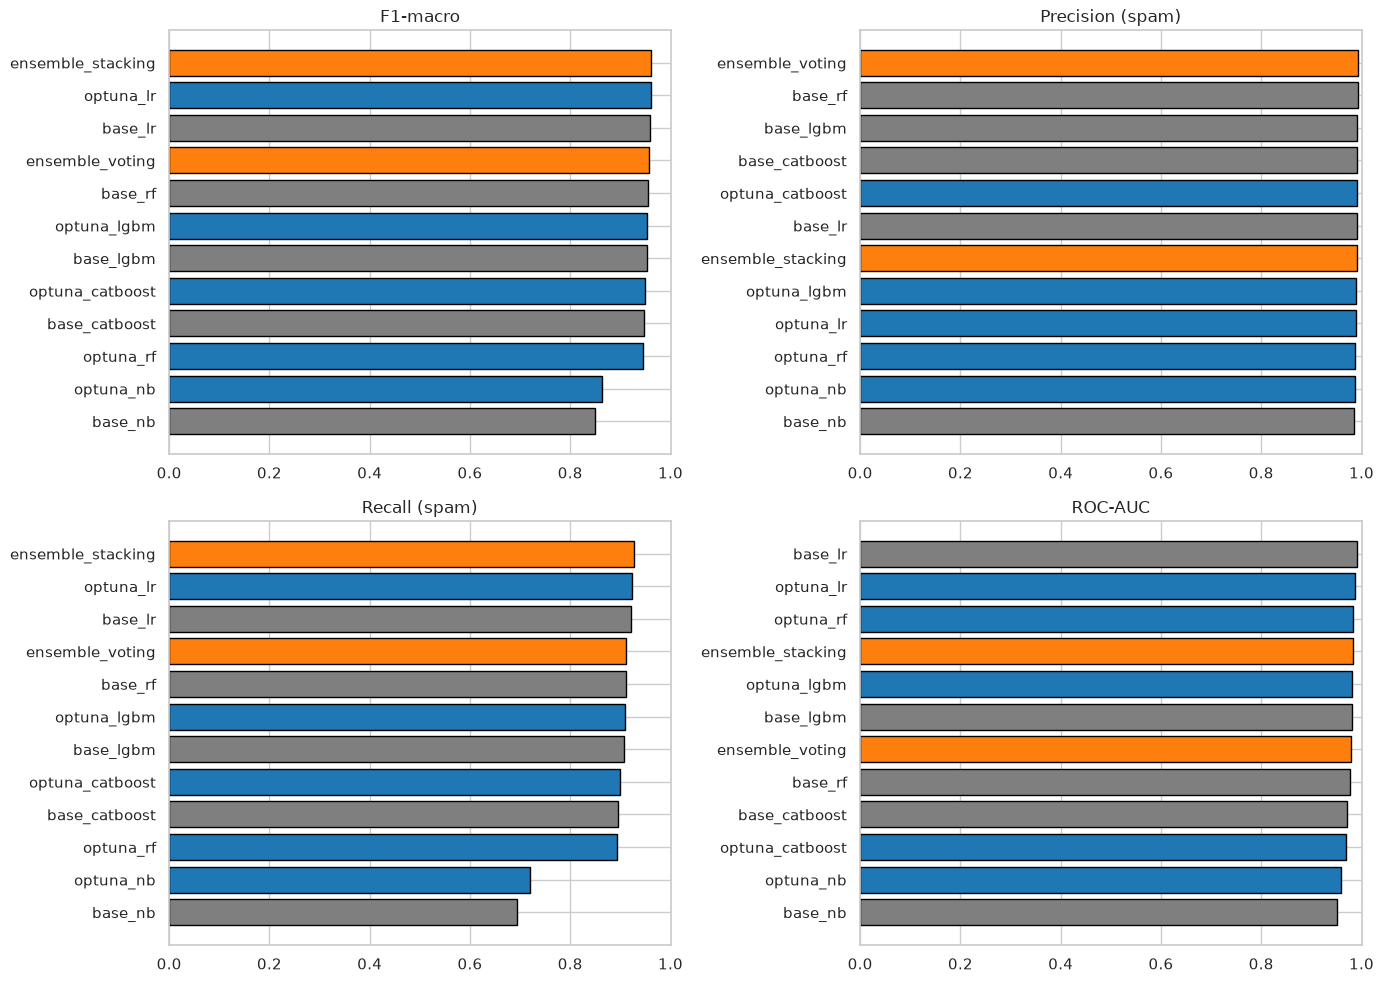

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ('f1_macro', 'F1-macro', axes[0, 0]),
    ('precision_spam', 'Precision (spam)', axes[0, 1]),
    ('recall_spam', 'Recall (spam)', axes[1, 0]),
    ('roc_auc', 'ROC-AUC', axes[1, 1]),
]

for metric, title, ax in metrics_to_plot:
    data = final_results.sort_values(metric, ascending=True)
    colors = ['tab:blue' if 'optuna' in m else 'tab:orange' if 'ensemble' in m else 'tab:gray'
              for m in data['model']]
    ax.barh(data['model'], data[metric], color=colors, edgecolor='black')
    ax.set_title(title)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## Анализ ошибок

Для лучшей модели (по F1-macro) анализируются false positives и false negatives. Выводятся топ-20 примеров каждого типа.

Выбор лучшей модели и получение предсказаний.

In [12]:
best_model_name = final_results.iloc[0]['model']
print(f'Лучшая модель: {best_model_name}')

if best_model_name.startswith('ensemble_'):
    best_model = ensemble_models[best_model_name.replace('ensemble_', '')]
    y_pred_best = best_model.predict(X_test)
elif best_model_name.startswith('optuna_'):
    key = best_model_name.replace('optuna_', '')
    best_model = optuna_results[key]
    X_eval = X_test_nc if key == 'nb' else X_test
    y_pred_best = best_model.predict(X_eval)
else:
    key = best_model_name.replace('base_', '')
    with open(INTERIM_DIR / 'base_models.pkl', 'rb') as f:
        base_models = pickle.load(f)
    best_model = base_models[key]
    X_eval = X_test_nc if key == 'nb' else X_test
    y_pred_best = best_model.predict(X_eval)

fp_mask = (y_test_arr == 0) & (y_pred_best == 1)
fn_mask = (y_test_arr == 1) & (y_pred_best == 0)

print(f'False Positives: {fp_mask.sum()}')
print(f'False Negatives: {fn_mask.sum()}')

Лучшая модель: ensemble_stacking
False Positives: 174
False Negatives: 1373


Топ-20 false positives (ham, ошибочно помечен как spam).

In [13]:
fp_indices = np.where(fp_mask)[0][:20]
print('False Positives (ham -> spam):\n')
for idx in fp_indices:
    text = str(df_test.iloc[idx]['text'])[:150]
    print(f'  [{idx}] {text}\n')

False Positives (ham -> spam):

  [8] From a friend

  [107] Родители нужны при личной подаче документов?

  [307] То-есть- минимальный порог на лингвистику 39 б? И даже на платную основу?

  [517] В лс кому?

  [522] https://admission.rudn.ru/undergraduate/competition_list/

  [556] Assalomu aleykum aka ,umumiy qancha summa ketarkan  tooshirishga rudnga

  [883] Лучшая компания супердискотеки ❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️

  [884] АЗИЗАА!!!!!🤍🤍🤍🤍

  [919] https://www.rudn.ru/education/educational-programs?level_of_training=489&mode_of_study%5B%5D=495

  [922] Привет. Платят только бюджетникам

  [1072] 178-355-049 00 Кыргыс Александра Аясовна

  [1135] 4. Возможна ли оплата за несколько лет вперед.

  [1375] Гасымова Нурана Назимовна 89393662727, nunu.gasimova1999@gmail.com

  [1467] Rudnda oqiysimi

  [1691] Turkey (Side ) 
Enjoy wonderful sunsets 🌅

  [2531] https://t.me/Thomas_Shelby_19

  [2649] No English here?

  [2687] https://vk.com/abi_pfur_mi_2022

  [2713] Беседа

Топ-20 false negatives (spam, пропущенный моделью).

In [14]:
fn_indices = np.where(fn_mask)[0][:20]
print('False Negatives (spam -> ham):\n')
for idx in fn_indices:
    text = str(df_test.iloc[idx]['text'])[:150]
    print(f'  [{idx}] {text}\n')

False Negatives (spam -> ham):

  [22626] دانیالللل

  [22632] پلن Ps5 چیشد :)

  [22633] اره v2ray

  [22641] جاست pc

  [22649] فهمیدم 2/15 هستی

  [22653] مهو مش شغال pdf

  [22658] معايا 2022

  [22685] هممونو

  [22699] 2000 مسدج؟🥲

  [22706] شب بخیر

  [22711] پشمام imdb 9.2

  [22734] سیو کرده R

  [22735] سیو کردم R🌊☯️

  [22744] المفروض 1.2

  [22756] داش تو ک 210 هی😂😂😂

  [22760] باب رابع 2023

  [22769] شانس مایه 176

  [22774] حضرت عباس

  [22775] 2 تا رزا هست

  [22781] ی ماهه 60 ب بالا



## Feature Importance

Анализ важности признаков для LightGBM, CatBoost и Logistic Regression. Выводятся топ-20 признаков.

Подготовка имён признаков: word TF-IDF + char TF-IDF + числовые.

In [15]:
with open(INTERIM_DIR / 'vectorizers.pkl', 'rb') as f:
    vec_data = pickle.load(f)
vectorizer = vec_data['vectorizer']
char_vectorizer = vec_data['char_vectorizer']

word_names = list(vectorizer.get_feature_names_out())
char_names = list(char_vectorizer.get_feature_names_out()) if char_vectorizer else []
num_names = NUMERICAL_COLUMNS
all_names = word_names + char_names + num_names
print(f'Всего признаков: {len(all_names)}')

Всего признаков: 7020


Feature importance для LightGBM.

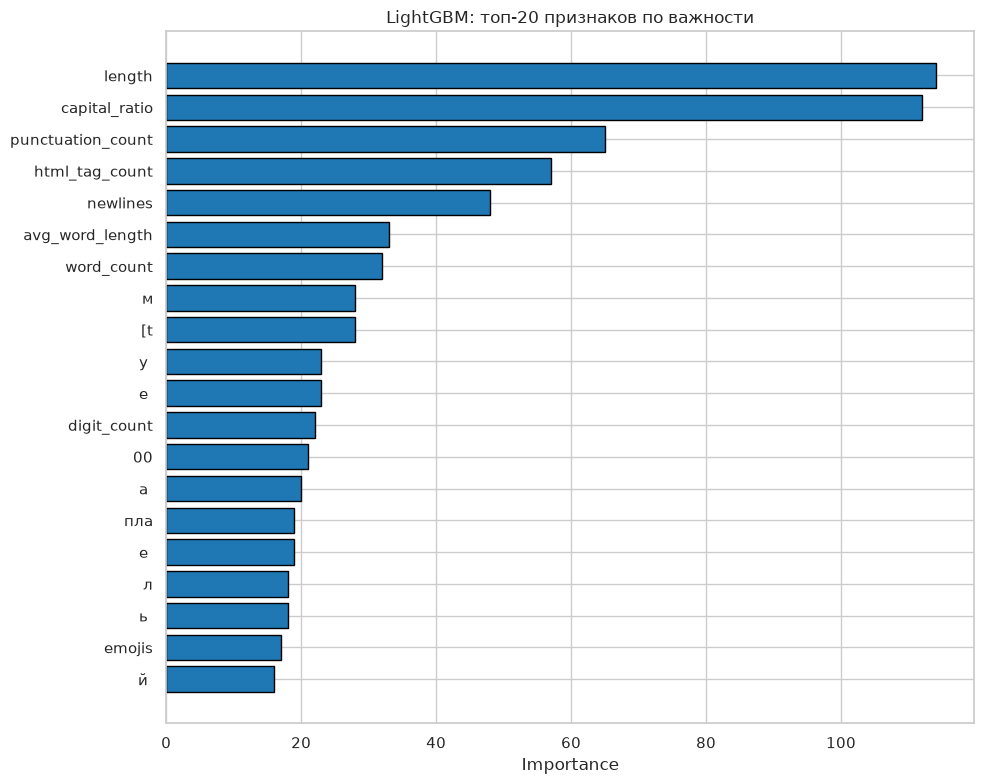

In [16]:
best_lgbm = optuna_results['lgbm']
if hasattr(best_lgbm, 'feature_importances_'):
    importances = best_lgbm.feature_importances_
    top20_idx = np.argsort(importances)[-20:][::-1]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(
        [all_names[i] if i < len(all_names) else f'feat_{i}' for i in top20_idx][::-1],
        importances[top20_idx][::-1],
        color='tab:blue', edgecolor='black',
    )
    ax.set_title('LightGBM: топ-20 признаков по важности')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

Feature importance для CatBoost.

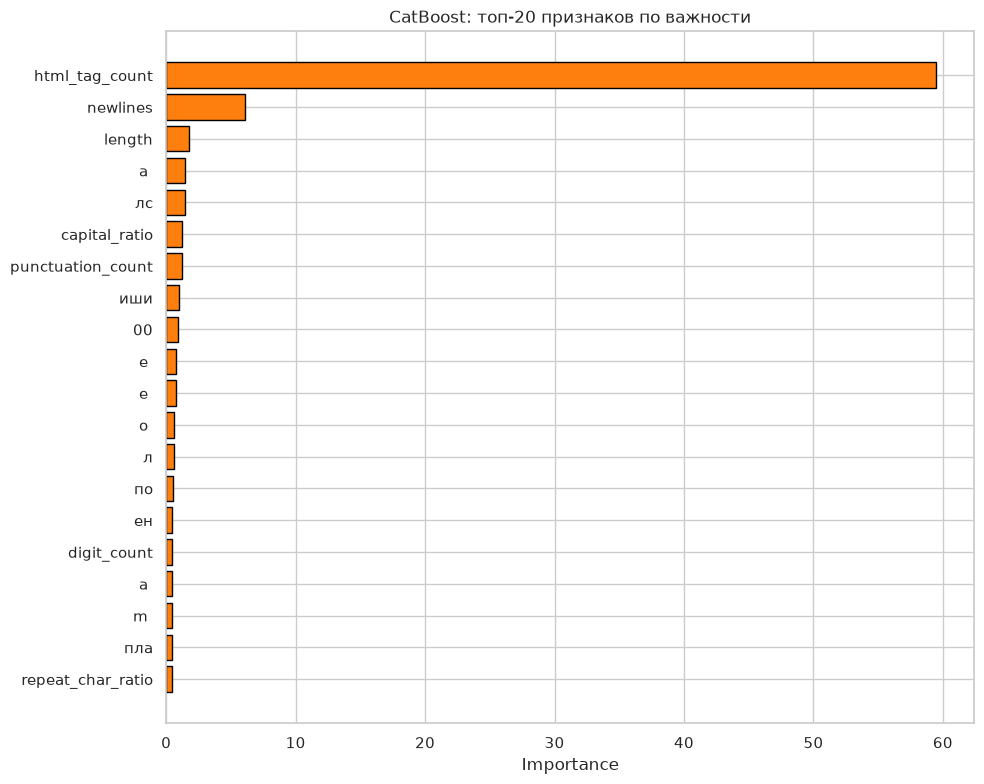

In [17]:
best_catboost = optuna_results['catboost']
if hasattr(best_catboost, 'feature_importances_'):
    importances = best_catboost.feature_importances_
    top20_idx = np.argsort(importances)[-20:][::-1]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(
        [all_names[i] if i < len(all_names) else f'feat_{i}' for i in top20_idx][::-1],
        importances[top20_idx][::-1],
        color='tab:orange', edgecolor='black',
    )
    ax.set_title('CatBoost: топ-20 признаков по важности')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

Коэффициенты Logistic Regression (красный = spam, синий = ham).

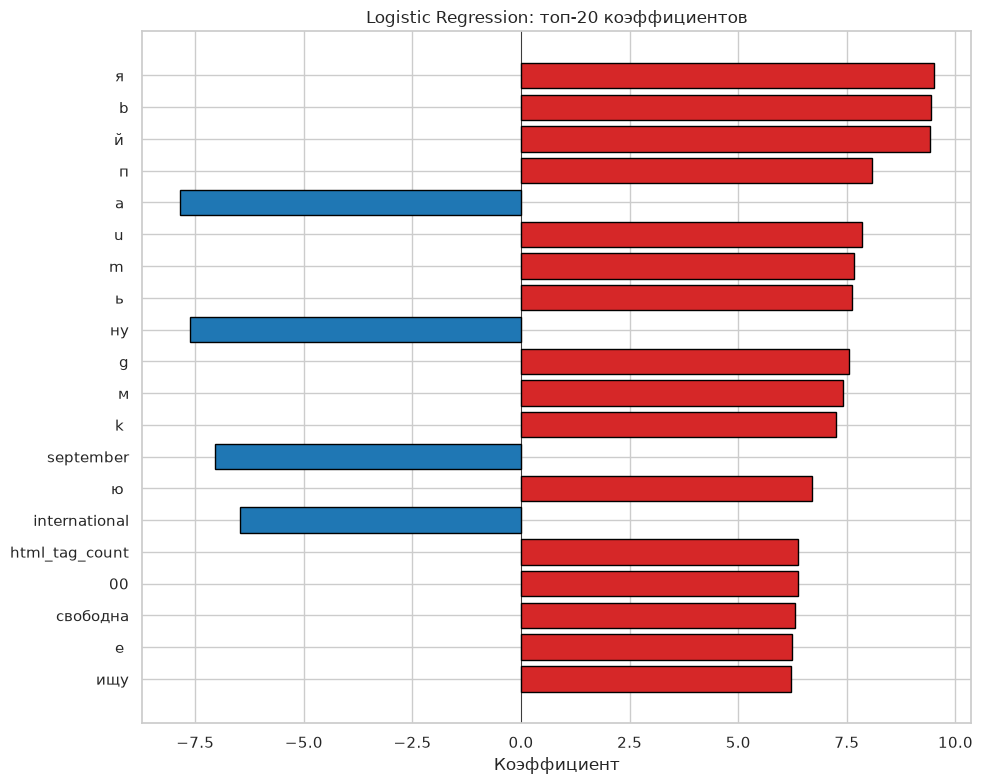

In [18]:
best_lr = optuna_results['lr']
if hasattr(best_lr, 'coef_'):
    coefs = best_lr.coef_[0]
    top20_idx = np.argsort(np.abs(coefs))[-20:][::-1]
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['tab:red' if c > 0 else 'tab:blue' for c in coefs[top20_idx]]
    ax.barh(
        [all_names[i] if i < len(all_names) else f'feat_{i}' for i in top20_idx][::-1],
        coefs[top20_idx][::-1],
        color=colors[::-1], edgecolor='black',
    )
    ax.set_title('Logistic Regression: топ-20 коэффициентов')
    ax.set_xlabel('Коэффициент')
    ax.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

## Сохранение результатов и моделей

Итоговая таблица сравнения сохраняется в CSV, модели и векторизаторы — в pickle-файлы.

In [19]:
final_results.to_csv(INTERIM_DIR / 'classical_baselines_results.csv', index=False)
print(f'Результаты сохранены: {INTERIM_DIR / "classical_baselines_results.csv"}')
print(f'Строк: {len(final_results)}')

Результаты сохранены: /home/sophrosyne/STANKIN_AntiSpam_Bot/data/interim/classical_baselines_results.csv
Строк: 12


Сохранение Optuna-моделей, векторизаторов и масштабатора.

In [20]:
scaler = vec_data['scaler']
save_models(
    optuna_results,
    vectorizer,
    scaler,
    char_vectorizer=char_vectorizer,
    output_dir=MODELS_DIR,
)
print(f'Модели сохранены в: {MODELS_DIR}')
print(f'Сохранено файлов: {len(optuna_results)} моделей + vectorizer + scaler + char_vectorizer')

Модели сохранены в: /home/sophrosyne/STANKIN_AntiSpam_Bot/models
Сохранено файлов: 5 моделей + vectorizer + scaler + char_vectorizer


## Демонстрация предсказания на новых сообщениях

In [21]:
example_messages = [
    'Здравствуйте, подскажите пожалуйста сроки поступления',
    'ЗАРАБОТОК В ИНТЕРНЕТЕ!!! Переходи по ссылке и зарабатывай 50000 в день!',
    'Спасибо за информацию',
    'КУПИ ДИПЛОМ ОПТОМ телеграм @diplom_buy',
]

print('Предсказания на примерах:\n')
for text in example_messages:
    pred, proba = predict_message(text, vectorizer, scaler, best_lr, char_vectorizer)
    label = 'SPAM' if pred == 1 else 'HAM'
    print(f'  Текст: {text[:80]}')
    print(f'  Предсказание: {label} (P(spam)={proba[1]:.4f})')
    print()

Предсказания на примерах:

  Текст: Здравствуйте, подскажите пожалуйста сроки поступления
  Предсказание: HAM (P(spam)=0.0001)

  Текст: ЗАРАБОТОК В ИНТЕРНЕТЕ!!! Переходи по ссылке и зарабатывай 50000 в день!
  Предсказание: SPAM (P(spam)=0.9999)

  Текст: Спасибо за информацию
  Предсказание: HAM (P(spam)=0.0034)

  Текст: КУПИ ДИПЛОМ ОПТОМ телеграм @diplom_buy
  Предсказание: SPAM (P(spam)=0.7791)

